In [3]:
import os
import warnings
import matplotlib.pyplot as plt
import pandas as pd

# 🛠️ 環境防線：全域忽略警告、解鎖中文字型與負號正常顯示
warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']  # Windows 微軟正黑體
plt.rcParams['axes.unicode_minus'] = False                # 確保負號正常顯示

# 1. 讀取第二階段留下的完全填答黃金資料集
processed_data_path = '../data/processed/02_core_variables_processed.csv'
df_processed = pd.read_csv(processed_data_path)

print(f"📦 成功從前一階段載入「完全填答黃金樣本池」：{df_processed.shape[0]} 筆")
print("-" * 75)

# 2. 建立二元涉入標籤 (0 = 未涉入, 1 = 有涉入)
# 級分 1.0 代表 0 次（未涉入），級分 2.0~6.0 代表 1 次以上（有涉入）
df_processed['Cig_User'] = (df_processed['CurrentCigaretteUse'] >= 2.0).astype(int)
df_processed['Alc_User'] = (df_processed['EverAlcoholUse'] >= 2.0).astype(int)
df_processed['Mj_User'] = (df_processed['CurrentMarijuaUse'] >= 2.0).astype(int)

# 3. 定義自訂函數，透過二元組合將學生精準分流至 8 個互斥組別
def assign_substance_group(row):
    cig = row['Cig_User']
    alc = row['Alc_User']
    mj = row['Mj_User']
    
    if cig == 0 and alc == 0 and mj == 0:
        return "G1: 完全清白組 (None)"
    elif cig == 1 and alc == 0 and mj == 0:
        return "G2: 單獨吸菸組 (Cig Only)"
    elif cig == 0 and alc == 1 and mj == 0:
        return "G3: 單獨飲酒組 (Alc Only)"
    elif cig == 0 and alc == 0 and mj == 1:
        return "G4: 單獨大麻組 (Mj Only)"
    elif cig == 1 and alc == 1 and mj == 0:
        return "G5: 菸酒共用組 (Cig + Alc)"
    elif cig == 1 and alc == 0 and mj == 1:
        return "G6: 菸大麻共用組 (Cig + Mj)"
    elif cig == 0 and alc == 1 and mj == 1:
        return "G7: 酒大麻共用組 (Alc + Mj)"
    elif cig == 1 and alc == 1 and mj == 1:
        return "G8: 三者全面涉入組 (All Three)"

# 4. 發動分流映射，為每位學生貼上唯一的群體標籤
df_processed['Substance_Group'] = df_processed.apply(assign_substance_group, axis=1)

# 5. 統計這 8 個組別的真實人數與比例分佈
group_counts = df_processed['Substance_Group'].value_counts().sort_index()
group_proportions = (df_processed['Substance_Group'].value_counts(normalize=True).sort_index() * 100).round(2)

# 6. 彙整成推論統計階段的起手點收報告表格
group_summary_df = pd.DataFrame({
    '群體人數 (N)': group_counts,
    '佔全體比例 (%)': group_proportions.astype(str) + '%'
})

print("🎯 【8 大互斥物質使用群體：樣本規模點收表】")
print("-" * 65)
display(group_summary_df)
print("=" * 75)

📦 成功從前一階段載入「完全填答黃金樣本池」：12093 筆
---------------------------------------------------------------------------
🎯 【8 大互斥物質使用群體：樣本規模點收表】
-----------------------------------------------------------------


,群體人數 (N),佔全體比例 (%)
Substance_Group,,
G1: 完全清白組 (None),2850,23.57%
G2: 單獨吸菸組 (Cig Only),52,0.43%
G3: 單獨飲酒組 (Alc Only),5849,48.37%
G4: 單獨大麻組 (Mj Only),46,0.38%
G5: 菸酒共用組 (Cig + Alc),946,7.82%
G6: 菸大麻共用組 (Cig + Mj),17,0.14%
G7: 酒大麻共用組 (Alc + Mj),958,7.92%
G8: 三者全面涉入組 (All Three),1375,11.37%


📊 正在繪製 8 大互斥物質使用群體之人數規模分佈圖...
🎉 長條圖已成功更新並存檔至: ../outputs/figures/03_substance_groups_distribution.png


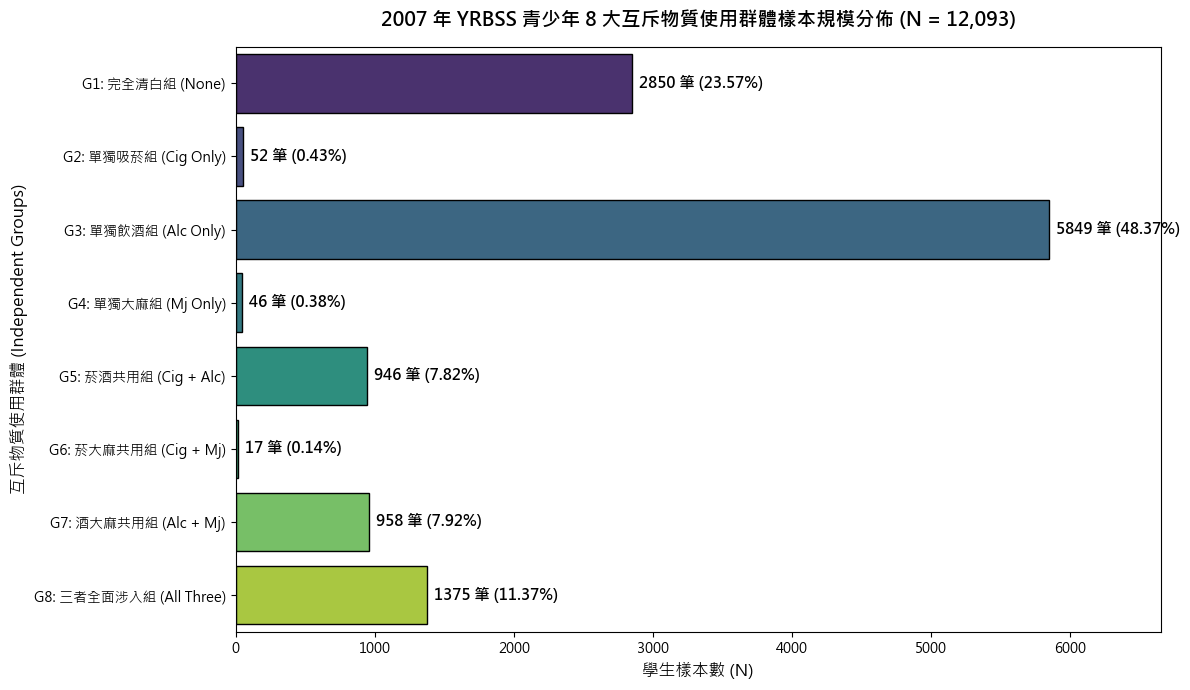

In [4]:
import os
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

# 🛠️ 環境防線：確保中文字型與無視警告
warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']
plt.rcParams['axes.unicode_minus'] = False

print("📊 正在繪製 8 大互斥物質使用群體之人數規模分佈圖...")

# 1. 提取剛才算好的數據進行排序與準備
plot_data = df_processed['Substance_Group'].value_counts().reset_index()
plot_data.columns = ['Substance_Group', '群體人數 (N)']
plot_data = plot_data.sort_values('Substance_Group')

# 2. 開啟畫布
plt.figure(figsize=(12, 7))
ax = sns.barplot(
    x='群體人數 (N)', 
    y='Substance_Group', 
    data=plot_data, 
    palette='viridis',     # 使用漸層高對比學術配色
    edgecolor='black'
)

# 3. 在長條圖右側優雅地加上「人數 (比例)」雙標籤
total_n = plot_data['群體人數 (N)'].sum()
for p in ax.patches:
    width = p.get_width()
    percentage = (width / total_n * 100).round(2)
    ax.text(
        width + 50, 
        p.get_y() + p.get_height() / 2, 
        f'{int(width)} 筆 ({percentage}%)', 
        ha='left', 
        va='center', 
        fontsize=11, 
        fontweight='bold'
    )

# 4. 圖表外觀與標題優化
plt.title('2007 年 YRBSS 青少年 8 大互斥物質使用群體樣本規模分佈 (N = 12,093)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('學生樣本數 (N)', fontsize=12)
plt.ylabel('互斥物質使用群體 (Independent Groups)', fontsize=12)
plt.xlim(0, plot_data['群體人數 (N)'].max() + 800)  # 留出右側空間給標籤
plt.tight_layout()

# 5. 安全存入指定輸出目錄 (編號 03)
output_fig_path = '../outputs/figures/03_substance_groups_distribution.png'
os.makedirs(os.path.dirname(output_fig_path), exist_ok=True)
plt.savefig(output_fig_path, dpi=300)

print(f"🎉 長條圖已成功更新並存檔至: {output_fig_path}")
plt.show()

In [26]:
import os
import pandas as pd
import statsmodels.formula.api as smf
from IPython.display import display, Math

print("⚡ 正在發動【8大互斥群體全物質微觀點收】與【組別獨立迴歸方程式模型】...")
print("=" * 105)

# 1. 確保數據基礎配置（古柯鹼減 1 轉換，所有物質自變數與應變數皆轉整數型態以利點收）
df_processed['Cocaine_Score'] = df_processed['EverCocaineUse'] - 1
df_processed['Cig_Int'] = df_processed['CurrentCigaretteUse'].astype(int)
df_processed['Alc_Int'] = df_processed['EverAlcoholUse'].astype(int)
df_processed['Mj_Int'] = df_processed['CurrentMarijuaUse'].astype(int)
df_processed['Cocaine_Int'] = df_processed['EverCocaineUse'].astype(int)  # ✨ 新增：古柯鹼原始級分整數化

# 核心增強：初始化用於收集 8 組迴歸與微觀人數統計數據的總清單
regression_records = []

# 2. 依據各組別的自變數活性，定義專屬的預測變數藍圖
group_blueprints = [
    ("G1: 完全清白組 (None)", []),
    ("G2: 單獨吸菸組 (Cig Only)", ['Cig_Int']),
    ("G3: 單獨飲酒組 (Alc Only)", ['Alc_Int']),
    ("G4: 單獨大麻組 (Mj Only)", ['Mj_Int']),
    ("G5: 菸酒共用組 (Cig + Alc)", ['Cig_Int', 'Alc_Int']),
    ("G6: 菸大麻共用組 (Cig + Mj)", ['Cig_Int', 'Mj_Int']),
    ("G7: 酒大麻共用組 (Alc + Mj)", ['Alc_Int', 'Mj_Int']),
    ("G8: 三者全面涉入組 (All Three)", ['Mj_Int', 'Cig_Int', 'Alc_Int'])
]

# 3. 迴圈發動：逐組進行微觀人數清點與專屬 LaTeX 方程式計算
for g_name, active_vars in group_blueprints:
    # 抽取該組別的學生子樣本池
    sub_df = df_processed[df_processed['Substance_Group'] == g_name]
    group_size = len(sub_df)

    print(f"🎯 【{g_name}】")
    print(f"   👥 總群體人數 (N) = {group_size} 筆")
    print(f"   📊 物質填答級分微觀人數分佈：")

    # ✨ 修正：將「古柯鹼」無縫納入點收矩陣中，並微調間距 (11s) 以確保排版完美對齊
    for var_name, label in [
        ('Cig_Int', '香菸'),
        ('Alc_Int', '酒精'),
        ('Mj_Int', '大麻'),
        ('Cocaine_Int', '古柯鹼')  # ✨ 新增：應變數人數分佈點收
    ]:
        counts = sub_df[var_name].value_counts().reindex(range(1, 7), fill_value=0)
        dist_list = [f"級分{i}: {counts[i]}人" for i in range(1, 7)]
        print(f"      🔹 {label} ({var_name:11s}) -> {', '.join(dist_list)}")

    print(f"   📝 專屬推論統計迴歸方程式 (LaTeX 渲染)：")

    # 初始化該組存檔用的字典特徵地圖（內含古柯鹼各級分存檔欄位）
    record = {
        '群體組別': g_name,
        '樣本數 (N)': group_size,
        '模型解釋力 (R-squared)': 0.0000,
        '截距項 (Intercept_Beta)': None,
        '大麻_Beta (x_i1)': None, '大麻_p值': None,
        '香菸_Beta (x_i2)': None, '香菸_p值': None,
        '酒精_Beta (z_i)': None, '酒精_p值': None,
        # ✨ 新增：自動將古柯鹼填答人數寫入 CSV 表格欄位中
        '古柯鹼_級分1 (0次)': sub_df['Cocaine_Int'].value_counts().reindex([1], fill_value=0).iloc[0],
        '古柯鹼_級分2 (1-2次)': sub_df['Cocaine_Int'].value_counts().reindex([2], fill_value=0).iloc[0],
        '古柯鹼_級分3 (3-9次)': sub_df['Cocaine_Int'].value_counts().reindex([3], fill_value=0).iloc[0],
        '古柯鹼_級分4 (10-19次)': sub_df['Cocaine_Int'].value_counts().reindex([4], fill_value=0).iloc[0],
        '古柯鹼_級分5 (20-39次)': sub_df['Cocaine_Int'].value_counts().reindex([5], fill_value=0).iloc[0],
        '古柯鹼_級分6 (40次以上)': sub_df['Cocaine_Int'].value_counts().reindex([6], fill_value=0).iloc[0],
        '專屬迴歸方程式 (LaTeX)': '',
    }

    # 情況 A：0維空間 (G1 完全清白組)
    if len(active_vars) == 0:
        cocaine_mean = sub_df['Cocaine_Score'].mean()
        master_latex_str = f"Y_i = {cocaine_mean:.4f}"
        display(Math(master_latex_str))
        print(f"      💡 局部模型解釋力 R-squared = 0.0000 (自變數鎖死無變異量)")

        record['截距項 (Intercept_Beta)'] = round(cocaine_mean, 4)
        record['專屬迴歸方程式 (LaTeX)'] = f"${master_latex_str}$"

    # 情況 B：具備活性自變數，可正常計算各項 β 係數 (G2 ~ G8)
    else:
        formula = "Cocaine_Score ~ " + " + ".join(active_vars)

        try:
            res = smf.ols(formula, data=sub_df).fit()
            intercept = res.params['Intercept']
            equation_parts = [f"{intercept:.4f}"]

            var_to_latex = {
                'Mj_Int': 'x_{i1}',  # 大麻
                'Cig_Int': 'x_{i2}',  # 香菸
                'Alc_Int': 'z_i',    # 酒精
            }

            for var in active_vars:
                beta = res.params[var]
                sign = "+" if beta >= 0 else "-"
                equation_parts.append(f"{sign} {abs(beta):.4f} {var_to_latex[var]}")

            master_latex_str = f"Y_i = " + " ".join(equation_parts) + " + \\varepsilon_i"
            display(Math(master_latex_str))

            print(f"      🔍 各自項 Beta 顯著性檢定：")
            for var in active_vars:
                p_val = res.pvalues[var]
                p_str = f"{p_val:.4f}" if p_val >= 0.0001 else "< 0.0001 (***)"
                print(f"         🔸 項【{var:11s}】的 \u03b2 = {res.params[var]:.4f} ｜ p-value = {p_str}")
            print(f"      💡 局部模型解釋力 R-squared = {res.rsquared:.4f}")

            # 填入統計數據到存檔字典
            record['模型解釋力 (R-squared)'] = round(res.rsquared, 4)
            record['截距項 (Intercept_Beta)'] = round(intercept, 4)
            record['專屬迴歸方程式 (LaTeX)'] = f"${master_latex_str}$"

            if 'Mj_Int' in active_vars:
                record['大麻_Beta (x_i1)'] = round(res.params['Mj_Int'], 4)
                record['大麻_p值'] = round(res.pvalues['Mj_Int'], 4) if res.pvalues['Mj_Int'] >= 0.0001 else '< 0.0001'
            if 'Cig_Int' in active_vars:
                record['香菸_Beta (x_i2)'] = round(res.params['Cig_Int'], 4)
                record['香菸_p值'] = round(res.pvalues['Cig_Int'], 4) if res.pvalues['Cig_Int'] >= 0.0001 else '< 0.0001'
            if 'Alc_Int' in active_vars:
                record['酒精_Beta (z_i)'] = round(res.params['Alc_Int'], 4)
                record['酒精_p值'] = round(res.pvalues['Alc_Int'], 4) if res.pvalues['Alc_Int'] >= 0.0001 else '< 0.0001'

        except Exception as e:
            print(f"      ❌ 統計警告：此組別因資料不足或極端不平衡無法估計: {e}")
            record['專屬迴歸方程式 (LaTeX)'] = f"無法估計: {str(e)}"

    # 將這一組撈到的寶貴數據塞進總陣列
    regression_records.append(record)
    print("-" * 105)

# =========================================================================
# ✨ 終點站：轉化成 DataFrame 並自動存檔至 outputs/tables/
# =========================================================================
print("\n💾 正在將 8 大組別的微觀填答分佈與迴歸統計指標匯出為實體表格檔案...")

df_output_tables = pd.DataFrame(regression_records)

# 建立輸出目錄
output_dir = '../outputs/tables/'
os.makedirs(output_dir, exist_ok=True)

# 定義檔案路徑
output_file_path = os.path.join(output_dir, '04_group_regression_summary.csv')

# 以 utf-8-sig 編碼存檔（完美相容 Windows Excel 開啟不亂碼）
df_output_tables.to_csv(output_file_path, index=False, encoding='utf-8-sig')

print(f"🎉 成果全面解鎖！包含【古柯鹼級分人數】的完整統計總表已成功存檔至: {output_file_path}")
print("📊 【新版匯出表格架構搶先點收】:")
display(df_output_tables)

⚡ 正在發動【8大互斥群體全物質微觀點收】與【組別獨立迴歸方程式模型】...
🎯 【G1: 完全清白組 (None)】
   👥 總群體人數 (N) = 2850 筆
   📊 物質填答級分微觀人數分佈：
      🔹 香菸 (Cig_Int    ) -> 級分1: 2850人, 級分2: 0人, 級分3: 0人, 級分4: 0人, 級分5: 0人, 級分6: 0人
      🔹 酒精 (Alc_Int    ) -> 級分1: 2850人, 級分2: 0人, 級分3: 0人, 級分4: 0人, 級分5: 0人, 級分6: 0人
      🔹 大麻 (Mj_Int     ) -> 級分1: 2850人, 級分2: 0人, 級分3: 0人, 級分4: 0人, 級分5: 0人, 級分6: 0人
      🔹 古柯鹼 (Cocaine_Int) -> 級分1: 2847人, 級分2: 2人, 級分3: 0人, 級分4: 0人, 級分5: 0人, 級分6: 1人
   📝 專屬推論統計迴歸方程式 (LaTeX 渲染)：


<IPython.core.display.Math object>

      💡 局部模型解釋力 R-squared = 0.0000 (自變數鎖死無變異量)
---------------------------------------------------------------------------------------------------------
🎯 【G2: 單獨吸菸組 (Cig Only)】
   👥 總群體人數 (N) = 52 筆
   📊 物質填答級分微觀人數分佈：
      🔹 香菸 (Cig_Int    ) -> 級分1: 0人, 級分2: 25人, 級分3: 8人, 級分4: 3人, 級分5: 6人, 級分6: 1人
      🔹 酒精 (Alc_Int    ) -> 級分1: 52人, 級分2: 0人, 級分3: 0人, 級分4: 0人, 級分5: 0人, 級分6: 0人
      🔹 大麻 (Mj_Int     ) -> 級分1: 52人, 級分2: 0人, 級分3: 0人, 級分4: 0人, 級分5: 0人, 級分6: 0人
      🔹 古柯鹼 (Cocaine_Int) -> 級分1: 51人, 級分2: 1人, 級分3: 0人, 級分4: 0人, 級分5: 0人, 級分6: 0人
   📝 專屬推論統計迴歸方程式 (LaTeX 渲染)：


<IPython.core.display.Math object>

      🔍 各自項 Beta 顯著性檢定：
         🔸 項【Cig_Int    】的 β = -0.0082 ｜ p-value = 0.4191
      💡 局部模型解釋力 R-squared = 0.0131
---------------------------------------------------------------------------------------------------------
🎯 【G3: 單獨飲酒組 (Alc Only)】
   👥 總群體人數 (N) = 5849 筆
   📊 物質填答級分微觀人數分佈：
      🔹 香菸 (Cig_Int    ) -> 級分1: 5849人, 級分2: 0人, 級分3: 0人, 級分4: 0人, 級分5: 0人, 級分6: 0人
      🔹 酒精 (Alc_Int    ) -> 級分1: 0人, 級分2: 1920人, 級分3: 1683人, 級分4: 871人, 級分5: 657人, 級分6: 410人
      🔹 大麻 (Mj_Int     ) -> 級分1: 5849人, 級分2: 0人, 級分3: 0人, 級分4: 0人, 級分5: 0人, 級分6: 0人
      🔹 古柯鹼 (Cocaine_Int) -> 級分1: 5701人, 級分2: 101人, 級分3: 26人, 級分4: 6人, 級分5: 5人, 級分6: 10人
   📝 專屬推論統計迴歸方程式 (LaTeX 渲染)：


...

<IPython.core.display.Math object>

      🔍 各自項 Beta 顯著性檢定：
         🔸 項【Alc_Int    】的 β = 0.0979 ｜ p-value = < 0.0001 (***)
         🔸 項【Mj_Int     】的 β = 0.0892 ｜ p-value = < 0.0001 (***)
      💡 局部模型解釋力 R-squared = 0.0579
---------------------------------------------------------------------------------------------------------
🎯 【G8: 三者全面涉入組 (All Three)】
   👥 總群體人數 (N) = 1375 筆
   📊 物質填答級分微觀人數分佈：
      🔹 香菸 (Cig_Int    ) -> 級分1: 0人, 級分2: 302人, 級分3: 182人, 級分4: 122人, 級分5: 173人, 級分6: 140人
      🔹 酒精 (Alc_Int    ) -> 級分1: 0人, 級分2: 74人, 級分3: 126人, 級分4: 152人, 級分5: 230人, 級分6: 282人
      🔹 大麻 (Mj_Int     ) -> 級分1: 0人, 級分2: 400人, 級分3: 309人, 級分4: 204人, 級分5: 161人, 級分6: 301人
      🔹 古柯鹼 (Cocaine_Int) -> 級分1: 926人, 級分2: 133人, 級分3: 110人, 級分4: 62人, 級分5: 41人, 級分6: 103人
   📝 專屬推論統計迴歸方程式 (LaTeX 渲染)：


<IPython.core.display.Math object>

      🔍 各自項 Beta 顯著性檢定：
         🔸 項【Mj_Int     】的 β = 0.2643 ｜ p-value = < 0.0001 (***)
         🔸 項【Cig_Int    】的 β = 0.0730 ｜ p-value = 0.0005
         🔸 項【Alc_Int    】的 β = 0.1998 ｜ p-value = < 0.0001 (***)
      💡 局部模型解釋力 R-squared = 0.1694
---------------------------------------------------------------------------------------------------------

💾 正在將 8 大組別的微觀填答分佈與迴歸統計指標匯出為實體表格檔案...
🎉 成果全面解鎖！包含【古柯鹼級分人數】的完整統計總表已成功存檔至: ../outputs/tables/04_group_regression_summary.csv
📊 【新版匯出表格架構搶先點收】:


,群體組別,樣本數 (N),模型解釋力 (R-squared),截距項 (Intercept_Beta),大麻_Beta (x_i1),大麻_p值,香菸_Beta (x_i2),香菸_p值,酒精_Beta (z_i),酒精_p值,古柯鹼_級分1 (0次),古柯鹼_級分2 (1-2次),古柯鹼_級分3 (3-9次),古柯鹼_級分4 (10-19次),古柯鹼_級分5 (20-39次),古柯鹼_級分6 (40次以上),專屬迴歸方程式 (LaTeX)
0,G1: 完全清白組 (None),2850,0.0000,0.0025,NaN,None,NaN,None,NaN,None,2847,2,0,0,0,1,$Y_i = 0.0025$
1,G2: 單獨吸菸組 (Cig Only),52,0.0131,0.0486,NaN,None,-0.0082,0.4191,NaN,None,51,1,0,0,0,0,$Y_i = 0.0486 - 0.0082 x_{i2} + \varepsilon_i$
2,G3: 單獨飲酒組 (Alc Only),5849,0.0202,-0.0638,NaN,None,NaN,None,0.0303,< 0.0001,5701,101,26,6,5,10,$Y_i = -0.0638 + 0.0303 z_i + \varepsilon_i$
3,G4: 單獨大麻組 (Mj Only),46,0.0249,-0.0622,0.0628,0.2949,NaN,None,NaN,None,42,3,0,0,1,0,$Y_i = -0.0622 + 0.0628 x_{i1} + \varepsilon_i$
4,G5: 菸酒共用組 (Cig + Alc),946,0.0694,-0.4661,NaN,None,0.0611,< 0.0001,0.1108,< 0.0001,803,70,30,18,12,13,$Y_i = -0.4661 + 0.0611 x_{i2} + 0.1108 z_i + ...
5,G6: 菸大麻共用組 (Cig + Mj),17,0.2222,-0.0690,0.0754,0.0714,-0.0385,0.2868,NaN,None,16,1,0,0,0,0,$Y_i = -0.0690 - 0.0385 x_{i2} + 0.0754 x_{i1}...
6,G7: 酒大麻共用組 (Alc + Mj),958,0.0579,-0.4577,0.0892,< 0.0001,NaN,None,0.0979,< 0.0001,846,52,17,19,8,16,$Y_i = -0.4577 + 0.0979 z_i + 0.0892 x_{i1} + ...
7,G8: 三者全面涉入組 (All Three),1375,0.1694,-1.5488,0.2643,< 0.0001,0.0730,0.0005,0.1998,< 0.0001,926,133,110,62,41,103,$Y_i = -1.5488 + 0.2643 x_{i1} + 0.0730 x_{i2}...


📈 正在發動【4D超空間修正技術】，全面升級 8 大群體之古柯鹼劑量效應圖...
🎉 跨維度劑量反應圖（G8 4D 空間立體膠囊球完美歸位！）已成功存檔至: ../outputs/figures/06_8_groups_dimensional_curves.png


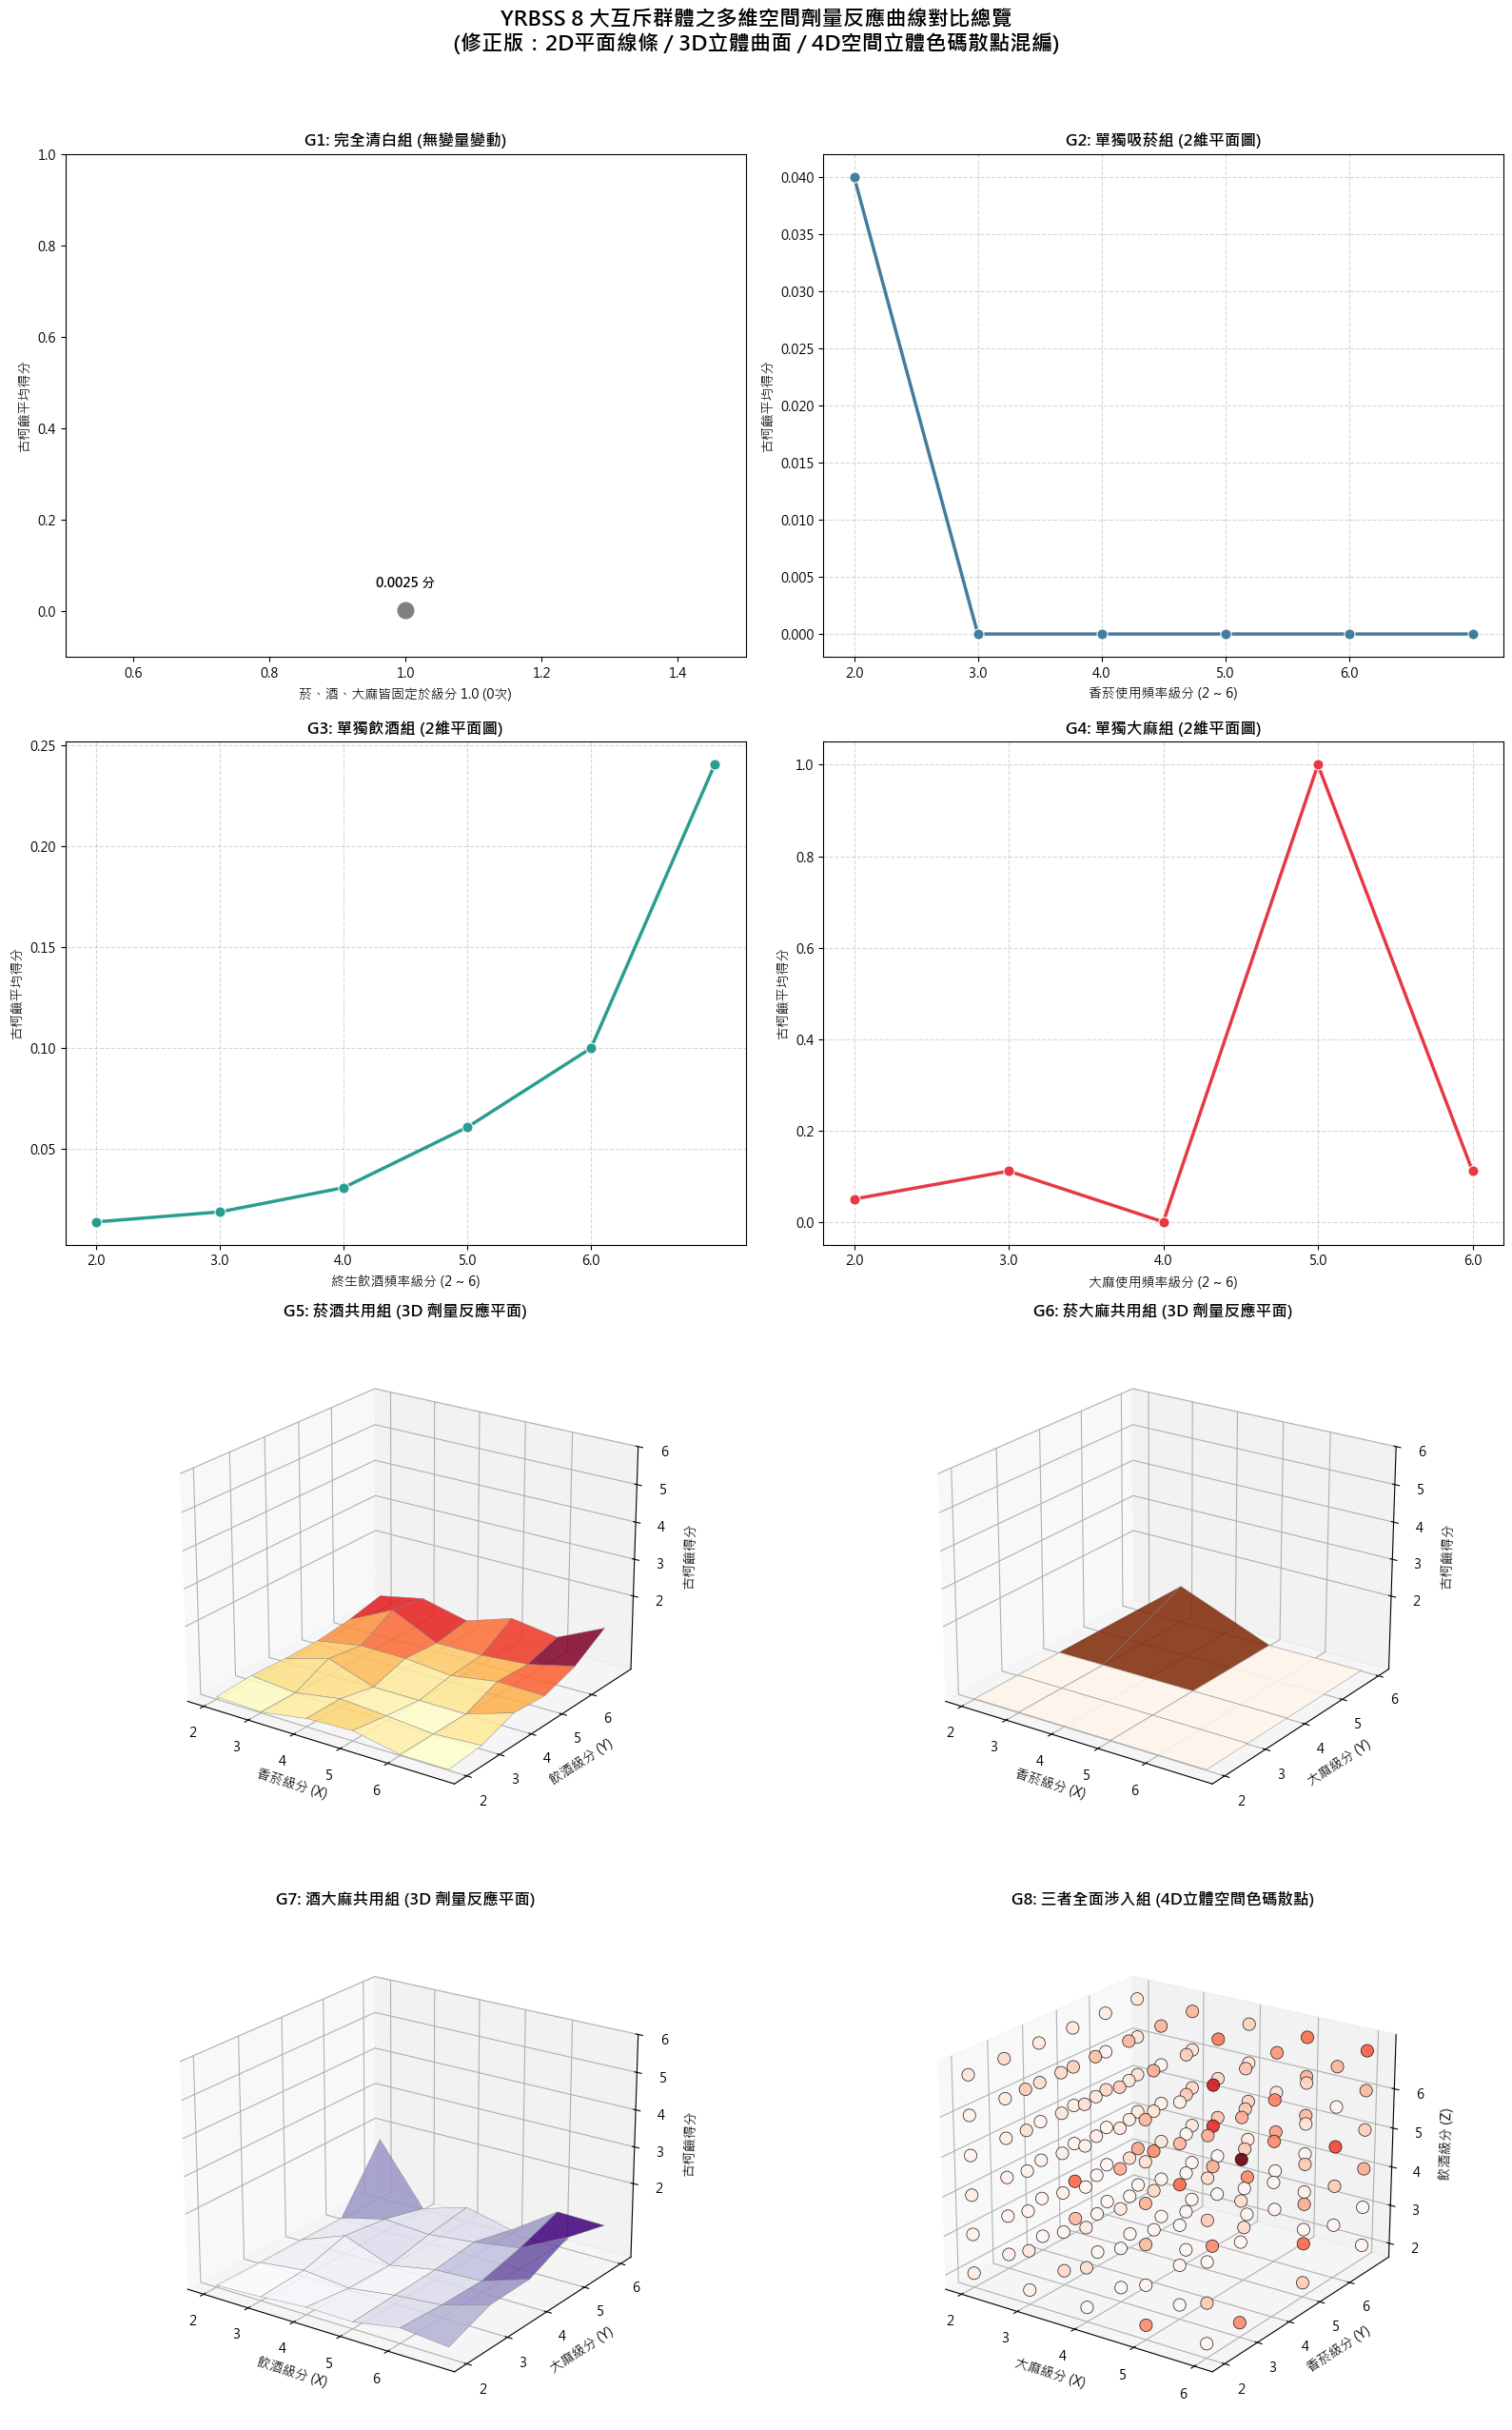

In [14]:
import os
import warnings
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # 導入 3D 繪圖引擎
import numpy as np                       # 用於建立 3D 網格矩陣
import seaborn as sns
import pandas as pd

# 🛠️ 環境防線：確保中文字型與無視警告
warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']
plt.rcParams['axes.unicode_minus'] = False

print("📈 正在發動【4D超空間修正技術】，全面升級 8 大群體之古柯鹼劑量效應圖...")

# 1. 確保古柯鹼得分已完成減 1 轉換 (0 代表從未吸食)
df_processed['Cocaine_Score'] = df_processed['EverCocaineUse'] - 1

# 💡 確保頻率皆為整數型態
df_processed['Cig_Int'] = df_processed['CurrentCigaretteUse'].astype(int)
df_processed['Alc_Int'] = df_processed['EverAlcoholUse'].astype(int)
df_processed['Mj_Int'] = df_processed['CurrentMarijuaUse'].astype(int)

# 2. ✨ 核心畫布架構重組：G5, G6, G7, G8 通通指定為立體 3D 畫布！
fig = plt.figure(figsize=(16, 26))
axes = {}
for i in range(8):
    if i in [4, 5, 6, 7]:  # G5, G6, G7, G8 全部升級為立體 3D 空間
        axes[i] = fig.add_subplot(4, 2, i+1, projection='3d')
    else:                  # G1, G2, G3, G4 保持標準 2D 平面
        axes[i] = fig.add_subplot(4, 2, i+1)

# =========================================================================
# 圖 1 (G1: 完全清白組) -> 0維固定點
# =========================================================================
df_g1 = df_processed[df_processed['Substance_Group'].str.startswith('G1')]
g1_mean = df_g1['Cocaine_Score'].mean()
axes[0].plot([1], [g1_mean], marker='o', markersize=12, color='gray')
axes[0].set_title('G1: 完全清白組 (無變量變動)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('菸、酒、大麻皆固定於級分 1.0 (0次)')
axes[0].set_ylabel('古柯鹼平均得分')
axes[0].set_xlim(0.5, 1.5)
axes[0].set_ylim(-0.1, 1.0)
axes[0].text(1, g1_mean + 0.05, f'{g1_mean:.4f} 分', ha='center', fontweight='bold')

# =========================================================================
# 圖 2 (G2: 單獨吸菸組) -> 2維平面圖
# =========================================================================
df_g2 = df_processed[df_processed['Substance_Group'].str.startswith('G2')]
sns.lineplot(data=df_g2, x='Cig_Int', y='Cocaine_Score', marker='o', markersize=8, ax=axes[1], color='#457B9D', linewidth=2.5, errorbar=None)
axes[1].set_title('G2: 單獨吸菸組 (2維平面圖)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('香菸使用頻率級分 (2 ~ 6)')
axes[1].set_ylabel('古柯鹼平均得分')

# =========================================================================
# 圖 3 (G3: 單獨飲酒組) -> 2維平面圖
# =========================================================================
df_g3 = df_processed[df_processed['Substance_Group'].str.startswith('G3')]
sns.lineplot(data=df_g3, x='Alc_Int', y='Cocaine_Score', marker='o', markersize=8, ax=axes[2], color='#2A9D8F', linewidth=2.5, errorbar=None)
axes[2].set_title('G3: 單獨飲酒組 (2維平面圖)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('終生飲酒頻率級分 (2 ~ 6)')
axes[2].set_ylabel('古柯鹼平均得分')

# =========================================================================
# 圖 4 (G4: 單獨大麻組) -> 2維平面圖
# =========================================================================
df_g4 = df_processed[df_processed['Substance_Group'].str.startswith('G4')]
sns.lineplot(data=df_g4, x='Mj_Int', y='Cocaine_Score', marker='o', markersize=8, ax=axes[3], color='#E63946', linewidth=2.5, errorbar=None)
axes[3].set_title('G4: 單獨大麻組 (2維平面圖)', fontsize=12, fontweight='bold')
axes[3].set_xlabel('大麻使用頻率級分 (2 ~ 6)')
axes[3].set_ylabel('古柯鹼平均得分')

# =========================================================================
# 圖 5 (G5: 菸酒共用組) -> 3D 劑量反應平面
# =========================================================================
df_g5 = df_processed[df_processed['Substance_Group'].str.startswith('G5')]
g5_3d = df_g5.groupby(['Cig_Int', 'Alc_Int'])['Cocaine_Score'].mean().reset_index()
pivot_g5 = g5_3d.pivot(index='Cig_Int', columns='Alc_Int', values='Cocaine_Score').fillna(0)
X_g5, Y_g5 = np.meshgrid(pivot_g5.index.values, pivot_g5.columns.values)
Z_g5 = pivot_g5.values.T

surf5 = axes[4].plot_surface(X_g5, Y_g5, Z_g5, cmap='YlOrRd', edgecolor='gray', linewidth=0.3, alpha=0.85)
axes[4].set_title('G5: 菸酒共用組 (3D 劑量反應平面)', fontsize=12, fontweight='bold', pad=10)
axes[4].set_xlabel('香菸級分 (X)', fontsize=10)
axes[4].set_ylabel('飲酒級分 (Y)', fontsize=10)
axes[4].set_zlabel('古柯鹼得分', fontsize=10)
axes[4].view_init(elev=22, azim=-55)

# =========================================================================
# 圖 6 (G6: 菸大麻共用組) -> 3D 劑量反應平面
# =========================================================================
df_g6 = df_processed[df_processed['Substance_Group'].str.startswith('G6')]
g6_3d = df_g6.groupby(['Cig_Int', 'Mj_Int'])['Cocaine_Score'].mean().reset_index()
pivot_g6 = g6_3d.pivot(index='Cig_Int', columns='Mj_Int', values='Cocaine_Score').fillna(0)
X_g6, Y_g6 = np.meshgrid(pivot_g6.index.values, pivot_g6.columns.values)
Z_g6 = pivot_g6.values.T

surf6 = axes[5].plot_surface(X_g6, Y_g6, Z_g6, cmap='Oranges', edgecolor='gray', linewidth=0.3, alpha=0.85)
axes[5].set_title('G6: 菸大麻共用組 (3D 劑量反應平面)', fontsize=12, fontweight='bold', pad=10)
axes[5].set_xlabel('香菸級分 (X)', fontsize=10)
axes[5].set_ylabel('大麻級分 (Y)', fontsize=10)
axes[5].set_zlabel('古柯鹼得分', fontsize=10)
axes[5].view_init(elev=22, azim=-55)

# =========================================================================
# 圖 7 (G7: 酒大麻共用組) -> 3D 劑量反應平面
# =========================================================================
df_g7 = df_processed[df_processed['Substance_Group'].str.startswith('G7')]
g7_3d = df_g7.groupby(['Alc_Int', 'Mj_Int'])['Cocaine_Score'].mean().reset_index()
pivot_g7 = g7_3d.pivot(index='Alc_Int', columns='Mj_Int', values='Cocaine_Score').fillna(0)
X_g7, Y_g7 = np.meshgrid(pivot_g7.index.values, pivot_g7.columns.values)
Z_g7 = pivot_g7.values.T

surf7 = axes[6].plot_surface(X_g7, Y_g7, Z_g7, cmap='Purples', edgecolor='gray', linewidth=0.3, alpha=0.85)
axes[6].set_title('G7: 酒大麻共用組 (3D 劑量反應平面)', fontsize=12, fontweight='bold', pad=10)
axes[6].set_xlabel('飲酒級分 (X)', fontsize=10)
axes[6].set_ylabel('大麻級分 (Y)', fontsize=10)
axes[6].set_zlabel('古柯鹼得分', fontsize=10)
axes[6].view_init(elev=22, azim=-55)

# =========================================================================
# ✨ 圖 8 (G8: 三者全面涉入組) -> 完美修正：4D 空間立體膠囊散點圖
# =========================================================================
df_g8 = df_processed[df_processed['Substance_Group'].str.startswith('G8')]

# 計算大麻、香菸、酒精三者交叉組合下，古柯鹼的最真實平均分（絕不漏掉任何一個變數！）
g8_4d_data = df_g8.groupby(['Mj_Int', 'Cig_Int', 'Alc_Int'])['Cocaine_Score'].mean().reset_index()

# 繪製 3D 散點，並用 c 參數將古柯鹼分數映射到火熱的 Reds 漸層
sc8 = axes[7].scatter3D(
    g8_4d_data['Mj_Int'],     # X軸：大麻
    g8_4d_data['Cig_Int'],     # Y軸：香菸
    g8_4d_data['Alc_Int'],     # Z軸：酒精
    c=g8_4d_data['Cocaine_Score'], 
    cmap='Reds', 
    s=90,                      # 放大點的大小，像一顆顆懸浮的膠囊數據球
    edgecolor='black', 
    linewidth=0.5,
    alpha=0.9
)

axes[7].set_title('G8: 三者全面涉入組 (4D立體空間色碼散點)', fontsize=12, fontweight='bold', pad=10)
axes[7].set_xlabel('大麻級分 (X)', fontsize=10)
axes[7].set_ylabel('香菸級分 (Y)', fontsize=10)
axes[7].set_zlabel('飲酒級分 (Z)', fontsize=10)
axes[7].view_init(elev=22, azim=-55)

# 3. 縝密配置各自維度的網格與刻度
for i in [1, 2, 3]: # 2D 平面組
    axes[i].set_xticks(range(2, 7))
    axes[i].set_xticklabels([f'{k}.0' for k in range(2, 7)])
    axes[i].grid(True, linestyle='--', alpha=0.5)

for i in [4, 5, 6, 7]: # 3D 立體組（包含全新 G8）
    axes[i].set_xticks(range(2, 7))
    axes[i].set_yticks(range(2, 7))
    axes[i].set_zticks(range(2, 7))
    axes[i].grid(True, linestyle='--', alpha=0.3)

# 4. 全域排版與標題優化
plt.suptitle('YRBSS 8 大互斥群體之多維空間劑量反應曲線對比總覽\n(修正版：2D平面線條 / 3D立體曲面 / 4D空間立體色碼散點混編)', 
             fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])

# 5. 安全儲存高解析度圖檔
output_fig_path = '../outputs/figures/06_8_groups_dimensional_curves.png'
os.makedirs(os.path.dirname(output_fig_path), exist_ok=True)
plt.savefig(output_fig_path, dpi=300)

print(f"🎉 跨維度劑量反應圖（G8 4D 空間立體膠囊球完美歸位！）已成功存檔至: {output_fig_path}")
plt.show()

In [25]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

print("⚡ 正在發動獨立一格的 One-way ANOVA 與 Tukey HSD 事後檢定...")
print("=" * 95)

# 1. 執行單因子變異數分析 (One-way ANOVA)
formula_anova = 'Cocaine_Score ~ C(Substance_Group)'
model_anova = ols(formula_anova, data=df_processed).fit()
anova_table = sm.stats.anova_lm(model_anova, typ=2)

print("📊 【第一階段：ANOVA 變異數分析總表】")
print("-" * 95)
display(anova_table)
print("-" * 95)

if anova_table['PR(>F)'].iloc[0] < 0.05:
    print(
        f"✅ ANOVA 結果極度顯著 (p < 0.0001)，證明 8 大群體對古柯鹼涉入度有『淨影響』。"
    )
    print(
        "\n📈 【第二階段：Tukey HSD 事後檢定 - 鎖定『大麻劑量效應』對比】"
    )
    print("=" * 95)

    # 執行全組合配對比較
    tukey = pairwise_tukeyhsd(
        endog=df_processed['Cocaine_Score'],
        groups=df_processed['Substance_Group'],
        alpha=0.05,
    )

    # 將 Tukey 結果轉為 DataFrame
    tukey_df = pd.DataFrame(
        data=tukey.summary().data[1:], columns=tukey.summary().data[0]
    )

    # 定義「有沒有大麻」的四組核心對照組
    core_marijuana_pairs = [
        ('G1: 完全清白組 (None)', 'G4: 單獨大麻組 (Mj Only)'),
        ('G2: 單獨吸菸組 (Cig Only)', 'G6: 菸大麻共用組 (Cig + Mj)'),
        ('G3: 單獨飲酒組 (Alc Only)', 'G7: 酒大麻共用組 (Alc + Mj)'),
        ('G5: 菸酒共用組 (Cig + Alc)', 'G8: 三者全面涉入組 (All Three)'),
    ]

    filtered_results = []
    for g1, g2 in core_marijuana_pairs:
        match = tukey_df[
            ((tukey_df['group1'] == g1) & (tukey_df['group2'] == g2))
            | ((tukey_df['group1'] == g2) & (tukey_df['group2'] == g1))
        ]
        filtered_results.append(match)

    # 彙整篩選結果
    summary_tukey = pd.concat(filtered_results).reset_index(drop=True)

    # 補上 '調整後 p 值 (p-adj)'，完美對齊 7 個欄位
    summary_tukey.columns = [
        '組別 A',
        '組別 B',
        '平均得分差 (meandiff)',
        '調整後 p 值 (p-adj)',
        '下界 (lower)',
        '上界 (upper)',
        '顯著拒絕 (reject)',
    ]

    # 補上直覺的學術標籤說明
    summary_tukey['統計學結論'] = summary_tukey['顯著拒絕 (reject)'].apply(
        lambda x: '⚠️ 差距顯著 (大麻加入引發暴衝)' if x else '⚪ 無顯著差異'
    )

    # 顯示最終篩選結果（加入 p-adj 欄位展現嚴謹度）
    display(
        summary_tukey[[
            '組別 A',
            '組別 B',
            '平均得分差 (meandiff)',
            '調整後 p 值 (p-adj)',
            '顯著拒絕 (reject)',
            '統計學結論',
        ]]
    )
    print('-' * 95)

    # =========================================================================
    # ✨ 終點站：將 Tukey HSD 篩選結果自動匯出為實體表格檔案存檔
    # =========================================================================
    print(
        '💾 正在將大麻淨效應之 Tukey HSD 事後檢定結果匯出為實體表格檔案...'
    )

    # 建立輸出目錄 (如果上一格創過，這裡會安全跳過)
    output_dir = '../outputs/tables/'
    os.makedirs(output_dir, exist_ok=True)

    # 定義檔案路徑，編號接續上一格的 04，命名為 05
    output_file_path = os.path.join(
        output_dir, '05_marijuana_impact_tukey.csv'
    )

    # 以 utf-8-sig 編碼存檔
    summary_tukey.to_csv(output_file_path, index=False, encoding='utf-8-sig')

    print(
        f'🎉 成果解鎖！Tukey HSD 核心對比總表已成功安全存檔至: {output_file_path}'
    )
    print('=' * 95)

⚡ 正在發動獨立一格的 One-way ANOVA 與 Tukey HSD 事後檢定...
📊 【第一階段：ANOVA 變異數分析總表】
-----------------------------------------------------------------------------------------------


,sum_sq,df,F,PR(>F)
C(Substance_Group),911.376116,7.0,289.452803,0.0
Residual,5435.862947,12085.0,NaN,NaN


-----------------------------------------------------------------------------------------------
✅ ANOVA 結果極度顯著 (p < 0.0001)，證明 8 大群體對古柯鹼涉入度有『淨影響』。

📈 【第二階段：Tukey HSD 事後檢定 - 鎖定『大麻劑量效應』對比】


,組別 A,組別 B,平均得分差 (meandiff),調整後 p 值 (p-adj),顯著拒絕 (reject),統計學結論
0,G1: 完全清白組 (None),G4: 單獨大麻組 (Mj Only),0.1497,0.8067,False,⚪ 無顯著差異
1,G2: 單獨吸菸組 (Cig Only),G6: 菸大麻共用組 (Cig + Mj),0.0396,1.0000,False,⚪ 無顯著差異
2,G3: 單獨飲酒組 (Alc Only),G7: 酒大麻共用組 (Alc + Mj),0.2250,0.0000,True,⚠️ 差距顯著 (大麻加入引發暴衝)
3,G5: 菸酒共用組 (Cig + Alc),G8: 三者全面涉入組 (All Three),0.5719,0.0000,True,⚠️ 差距顯著 (大麻加入引發暴衝)


-----------------------------------------------------------------------------------------------
💾 正在將大麻淨效應之 Tukey HSD 事後檢定結果匯出為實體表格檔案...
🎉 成果解鎖！Tukey HSD 核心對比總表已成功安全存檔至: ../outputs/tables/05_marijuana_impact_tukey.csv


In [27]:
import os
import pandas as pd
import statsmodels.formula.api as smf
from IPython.display import display, Math

print("⚡ 正在發動【8大互斥群體全物質微觀點收】與【組別獨立迴歸方程式模型 - 海洛因版】...")
print("=" * 105)

# 1. 確保數據基礎配置（海洛因減 1 轉換，所有物質自變數與應變數皆轉整數型態以利點收）
df_processed['Heroin_Score'] = df_processed['EverHeroinUse'] - 1
df_processed['Cig_Int'] = df_processed['CurrentCigaretteUse'].astype(int)
df_processed['Alc_Int'] = df_processed['EverAlcoholUse'].astype(int)
df_processed['Mj_Int'] = df_processed['CurrentMarijuaUse'].astype(int)
df_processed['Heroin_Int'] = df_processed['EverHeroinUse'].astype(int)  # 海洛因原始級分整數化

# 初始化用於收集 8 組海洛因迴歸與微觀人數統計數據的總清單
heroin_regression_records = []

# 2. 依據各組別的自變數活性，定義專屬的預測變數藍圖
group_blueprints = [
    ("G1: 完全清白組 (None)", []),
    ("G2: 單獨吸菸組 (Cig Only)", ['Cig_Int']),
    ("G3: 單獨飲酒組 (Alc Only)", ['Alc_Int']),
    ("G4: 單獨大麻組 (Mj Only)", ['Mj_Int']),
    ("G5: 菸酒共用組 (Cig + Alc)", ['Cig_Int', 'Alc_Int']),
    ("G6: 菸大麻共用組 (Cig + Mj)", ['Cig_Int', 'Mj_Int']),
    ("G7: 酒大麻共用組 (Alc + Mj)", ['Alc_Int', 'Mj_Int']),
    ("G8: 三者全面涉入組 (All Three)", ['Mj_Int', 'Cig_Int', 'Alc_Int'])
]

# 3. 迴圈發動：逐組進行微觀人數清點與專屬 LaTeX 方程式計算
for g_name, active_vars in group_blueprints:
    # 抽取該組別的學生子樣本池
    sub_df = df_processed[df_processed['Substance_Group'] == g_name]
    group_size = len(sub_df)

    print(f"🎯 【{g_name}】")
    print(f"   👥 總群體人數 (N) = {group_size} 筆")
    print(f"   📊 物質填答級分微觀人數分佈：")

    # 全面點收：香菸、酒精、大麻，以及全新的「海洛因」在 1~6 級分各自的真實填答人數
    for var_name, label in [
        ('Cig_Int', '香菸'),
        ('Alc_Int', '酒精'),
        ('Mj_Int', '大麻'),
        ('Heroin_Int', '海洛因')
    ]:
        counts = sub_df[var_name].value_counts().reindex(range(1, 7), fill_value=0)
        dist_list = [f"級分{i}: {counts[i]}人" for i in range(1, 7)]
        print(f"      🔹 {label} ({var_name:11s}) -> {', '.join(dist_list)}")

    print(f"   📝 專屬推論統計迴歸方程式 (LaTeX 渲染)：")

    # 初始化該組存檔用的字典特徵地圖（內含海洛因各級分真實計數欄位）
    record = {
        '群體組別': g_name,
        '樣本數 (N)': group_size,
        '模型解釋力 (R-squared)': 0.0000,
        '截距項 (Intercept_Beta)': None,
        '大麻_Beta (x_i1)': None, '大麻_p值': None,
        '香菸_Beta (x_i2)': None, '香菸_p值': None,
        '酒精_Beta (z_i)': None, '酒精_p值': None,
        '海洛因_級分1 (0次)': sub_df['Heroin_Int'].value_counts().reindex([1], fill_value=0).iloc[0],
        '海洛因_級分2 (1-2次)': sub_df['Heroin_Int'].value_counts().reindex([2], fill_value=0).iloc[0],
        '海洛因_級分3 (3-9次)': sub_df['Heroin_Int'].value_counts().reindex([3], fill_value=0).iloc[0],
        '海洛因_級分4 (10-19次)': sub_df['Heroin_Int'].value_counts().reindex([4], fill_value=0).iloc[0],
        '海洛因_級分5 (20-39次)': sub_df['Heroin_Int'].value_counts().reindex([5], fill_value=0).iloc[0],
        '海洛因_級分6 (40次以上)': sub_df['Heroin_Int'].value_counts().reindex([6], fill_value=0).iloc[0],
        '專屬迴歸方程式 (LaTeX)': '',
    }

    # 情況 A：0維空間 (G1 完全清白組)
    if len(active_vars) == 0:
        heroin_mean = sub_df['Heroin_Score'].mean()
        master_latex_str = f"Y_i = {heroin_mean:.4f}"
        display(Math(master_latex_str))
        print(f"      💡 局部模型解釋力 R-squared = 0.0000 (自變數鎖死無變異量)")

        record['截距項 (Intercept_Beta)'] = round(heroin_mean, 4)
        record['專屬迴歸方程式 (LaTeX)'] = f"${master_latex_str}$"

    # 情況 B：具備活性自變數，可正常計算各項 β 係數 (G2 ~ G8)
    else:
        formula = "Heroin_Score ~ " + " + ".join(active_vars)

        try:
            res = smf.ols(formula, data=sub_df).fit()
            intercept = res.params['Intercept']
            equation_parts = [f"{intercept:.4f}"]

            var_to_latex = {
                'Mj_Int': 'x_{i1}',  # 大麻
                'Cig_Int': 'x_{i2}',  # 香菸
                'Alc_Int': 'z_i',    # 酒精
            }

            for var in active_vars:
                beta = res.params[var]
                sign = "+" if beta >= 0 else "-"
                equation_parts.append(f"{sign} {abs(beta):.4f} {var_to_latex[var]}")

            master_latex_str = f"Y_i = " + " ".join(equation_parts) + " + \\varepsilon_i"
            display(Math(master_latex_str))

            print(f"      🔍 各自項 Beta 顯著性檢定：")
            for var in active_vars:
                p_val = res.pvalues[var]
                p_str = f"{p_val:.4f}" if p_val >= 0.0001 else "< 0.0001 (***)"
                print(f"         🔸 項【{var:11s}】的 \u03b2 = {res.params[var]:.4f} ｜ p-value = {p_str}")
            print(f"      💡 局部模型解釋力 R-squared = {res.rsquared:.4f}")

            # 填入統計數據到存檔字典
            record['模型解釋力 (R-squared)'] = round(res.rsquared, 4)
            record['截距項 (Intercept_Beta)'] = round(intercept, 4)
            record['專屬迴歸方程式 (LaTeX)'] = f"${master_latex_str}$"

            if 'Mj_Int' in active_vars:
                record['大麻_Beta (x_i1)'] = round(res.params['Mj_Int'], 4)
                record['大麻_p值'] = round(res.pvalues['Mj_Int'], 4) if res.pvalues['Mj_Int'] >= 0.0001 else '< 0.0001'
            if 'Cig_Int' in active_vars:
                record['香菸_Beta (x_i2)'] = round(res.params['Cig_Int'], 4)
                record['香菸_p值'] = round(res.pvalues['Cig_Int'], 4) if res.pvalues['Cig_Int'] >= 0.0001 else '< 0.0001'
            if 'Alc_Int' in active_vars:
                record['酒精_Beta (z_i)'] = round(res.params['Alc_Int'], 4)
                record['酒精_p值'] = round(res.pvalues['Alc_Int'], 4) if res.pvalues['Alc_Int'] >= 0.0001 else '< 0.0001'

        except Exception as e:
            print(f"      ❌ 統計警告：此組別因資料不足或極端不平衡無法估計: {e}")
            record['專屬迴歸方程式 (LaTeX)'] = f"無法估計: {str(e)}"

    # 將這一組撈到的寶貴數據塞進總陣列
    heroin_regression_records.append(record)
    print("-" * 105)

# =========================================================================
# ✨ 終點站：將海洛因統計結果匯出為實體表格檔案
# =========================================================================
print("\n💾 正在將 8 大組別的海洛因微觀填答分佈與迴歸統計指標匯出為實體表格檔案...")

df_heroin_tables = pd.DataFrame(heroin_regression_records)

# 建立輸出目錄
output_dir = '../outputs/tables/'
os.makedirs(output_dir, exist_ok=True)

# 定義檔案路徑 (接續編號命名為 06)
output_file_path = os.path.join(output_dir, '06_heroin_group_regression_summary.csv')

# 以 utf-8-sig 編碼存檔（完美相容 Excel）
df_heroin_tables.to_csv(output_file_path, index=False, encoding='utf-8-sig')

print(f"🎉 成果全面解鎖！包含【海洛因級分人數】的完整統計總表已成功存檔至: {output_file_path}")
print("📊 【海洛因匯出表格架構搶先點收】:")
display(df_heroin_tables)

⚡ 正在發動【8大互斥群體全物質微觀點收】與【組別獨立迴歸方程式模型 - 海洛因版】...
🎯 【G1: 完全清白組 (None)】
   👥 總群體人數 (N) = 2850 筆
   📊 物質填答級分微觀人數分佈：
      🔹 香菸 (Cig_Int    ) -> 級分1: 2850人, 級分2: 0人, 級分3: 0人, 級分4: 0人, 級分5: 0人, 級分6: 0人
      🔹 酒精 (Alc_Int    ) -> 級分1: 2850人, 級分2: 0人, 級分3: 0人, 級分4: 0人, 級分5: 0人, 級分6: 0人
      🔹 大麻 (Mj_Int     ) -> 級分1: 2850人, 級分2: 0人, 級分3: 0人, 級分4: 0人, 級分5: 0人, 級分6: 0人
      🔹 海洛因 (Heroin_Int ) -> 級分1: 2850人, 級分2: 0人, 級分3: 0人, 級分4: 0人, 級分5: 0人, 級分6: 0人
   📝 專屬推論統計迴歸方程式 (LaTeX 渲染)：


<IPython.core.display.Math object>

      💡 局部模型解釋力 R-squared = 0.0000 (自變數鎖死無變異量)
---------------------------------------------------------------------------------------------------------
🎯 【G2: 單獨吸菸組 (Cig Only)】
   👥 總群體人數 (N) = 52 筆
   📊 物質填答級分微觀人數分佈：
      🔹 香菸 (Cig_Int    ) -> 級分1: 0人, 級分2: 25人, 級分3: 8人, 級分4: 3人, 級分5: 6人, 級分6: 1人
      🔹 酒精 (Alc_Int    ) -> 級分1: 52人, 級分2: 0人, 級分3: 0人, 級分4: 0人, 級分5: 0人, 級分6: 0人
      🔹 大麻 (Mj_Int     ) -> 級分1: 52人, 級分2: 0人, 級分3: 0人, 級分4: 0人, 級分5: 0人, 級分6: 0人
      🔹 海洛因 (Heroin_Int ) -> 級分1: 52人, 級分2: 0人, 級分3: 0人, 級分4: 0人, 級分5: 0人, 級分6: 0人
   📝 專屬推論統計迴歸方程式 (LaTeX 渲染)：


<IPython.core.display.Math object>

      🔍 各自項 Beta 顯著性檢定：
         🔸 項【Cig_Int    】的 β = 0.0000 ｜ p-value = < 0.0001 (***)
      💡 局部模型解釋力 R-squared = nan
---------------------------------------------------------------------------------------------------------
🎯 【G3: 單獨飲酒組 (Alc Only)】
   👥 總群體人數 (N) = 5849 筆
   📊 物質填答級分微觀人數分佈：
      🔹 香菸 (Cig_Int    ) -> 級分1: 5849人, 級分2: 0人, 級分3: 0人, 級分4: 0人, 級分5: 0人, 級分6: 0人
      🔹 酒精 (Alc_Int    ) -> 級分1: 0人, 級分2: 1920人, 級分3: 1683人, 級分4: 871人, 級分5: 657人, 級分6: 410人
      🔹 大麻 (Mj_Int     ) -> 級分1: 5849人, 級分2: 0人, 級分3: 0人, 級分4: 0人, 級分5: 0人, 級分6: 0人
      🔹 海洛因 (Heroin_Int ) -> 級分1: 5827人, 級分2: 17人, 級分3: 2人, 級分4: 0人, 級分5: 0人, 級分6: 3人
   📝 專屬推論統計迴歸方程式 (LaTeX 渲染)：


...

<IPython.core.display.Math object>

      🔍 各自項 Beta 顯著性檢定：
         🔸 項【Alc_Int    】的 β = 0.0003 ｜ p-value = 0.9727
         🔸 項【Mj_Int     】的 β = 0.0207 ｜ p-value = 0.0255
      💡 局部模型解釋力 R-squared = 0.0054
---------------------------------------------------------------------------------------------------------
🎯 【G8: 三者全面涉入組 (All Three)】
   👥 總群體人數 (N) = 1375 筆
   📊 物質填答級分微觀人數分佈：
      🔹 香菸 (Cig_Int    ) -> 級分1: 0人, 級分2: 302人, 級分3: 182人, 級分4: 122人, 級分5: 173人, 級分6: 140人
      🔹 酒精 (Alc_Int    ) -> 級分1: 0人, 級分2: 74人, 級分3: 126人, 級分4: 152人, 級分5: 230人, 級分6: 282人
      🔹 大麻 (Mj_Int     ) -> 級分1: 0人, 級分2: 400人, 級分3: 309人, 級分4: 204人, 級分5: 161人, 級分6: 301人
      🔹 海洛因 (Heroin_Int ) -> 級分1: 1248人, 級分2: 43人, 級分3: 15人, 級分4: 11人, 級分5: 6人, 級分6: 52人
   📝 專屬推論統計迴歸方程式 (LaTeX 渲染)：


<IPython.core.display.Math object>

      🔍 各自項 Beta 顯著性檢定：
         🔸 項【Mj_Int     】的 β = 0.1334 ｜ p-value = < 0.0001 (***)
         🔸 項【Cig_Int    】的 β = 0.0539 ｜ p-value = 0.0003
         🔸 項【Alc_Int    】的 β = 0.0679 ｜ p-value = 0.0002
      💡 局部模型解釋力 R-squared = 0.0885
---------------------------------------------------------------------------------------------------------

💾 正在將 8 大組別的海洛因微觀填答分佈與迴歸統計指標匯出為實體表格檔案...
🎉 成果全面解鎖！包含【海洛因級分人數】的完整統計總表已成功存檔至: ../outputs/tables/06_heroin_group_regression_summary.csv
📊 【海洛因匯出表格架構搶先點收】:


,群體組別,樣本數 (N),模型解釋力 (R-squared),截距項 (Intercept_Beta),大麻_Beta (x_i1),大麻_p值,香菸_Beta (x_i2),香菸_p值,酒精_Beta (z_i),酒精_p值,海洛因_級分1 (0次),海洛因_級分2 (1-2次),海洛因_級分3 (3-9次),海洛因_級分4 (10-19次),海洛因_級分5 (20-39次),海洛因_級分6 (40次以上),專屬迴歸方程式 (LaTeX)
0,G1: 完全清白組 (None),2850,0.0000,0.0000,NaN,None,NaN,None,NaN,NaN,2850,0,0,0,0,0,$Y_i = 0.0000$
1,G2: 單獨吸菸組 (Cig Only),52,NaN,0.0000,NaN,None,0.0000,< 0.0001,NaN,NaN,52,0,0,0,0,0,$Y_i = 0.0000 + 0.0000 x_{i2} + \varepsilon_i$
2,G3: 單獨飲酒組 (Alc Only),5849,0.0004,-0.0001,NaN,None,NaN,None,0.0018,0.1157,5827,17,2,0,0,3,$Y_i = -0.0001 + 0.0018 z_i + \varepsilon_i$
3,G4: 單獨大麻組 (Mj Only),46,NaN,0.0000,0.0000,< 0.0001,NaN,None,NaN,NaN,46,0,0,0,0,0,$Y_i = 0.0000 + 0.0000 x_{i1} + \varepsilon_i$
4,G5: 菸酒共用組 (Cig + Alc),946,0.0101,-0.0644,NaN,None,0.0127,0.0441,0.0127,0.0852,923,12,6,2,1,2,$Y_i = -0.0644 + 0.0127 x_{i2} + 0.0127 z_i + ...
5,G6: 菸大麻共用組 (Cig + Mj),17,0.0666,0.0308,-0.0287,0.5088,0.0354,0.3691,NaN,NaN,16,1,0,0,0,0,$Y_i = 0.0308 + 0.0354 x_{i2} - 0.0287 x_{i1} ...
6,G7: 酒大麻共用組 (Alc + Mj),958,0.0054,-0.0233,0.0207,0.0255,NaN,None,0.0003,0.9727,940,10,3,1,0,4,$Y_i = -0.0233 + 0.0003 z_i + 0.0207 x_{i1} + ...
7,G8: 三者全面涉入組 (All Three),1375,0.0885,-0.8457,0.1334,< 0.0001,0.0539,0.0003,0.0679,0.0002,1248,43,15,11,6,52,$Y_i = -0.8457 + 0.1334 x_{i1} + 0.0539 x_{i2}...


正在繪製 8 大互斥群體之海洛因劑量效應多維度圖表...
海洛因多維空間劑量反應圖繪製完成，圖檔已儲存至: ../outputs/figures/08_heroin_8_groups_dimensional_curves.png


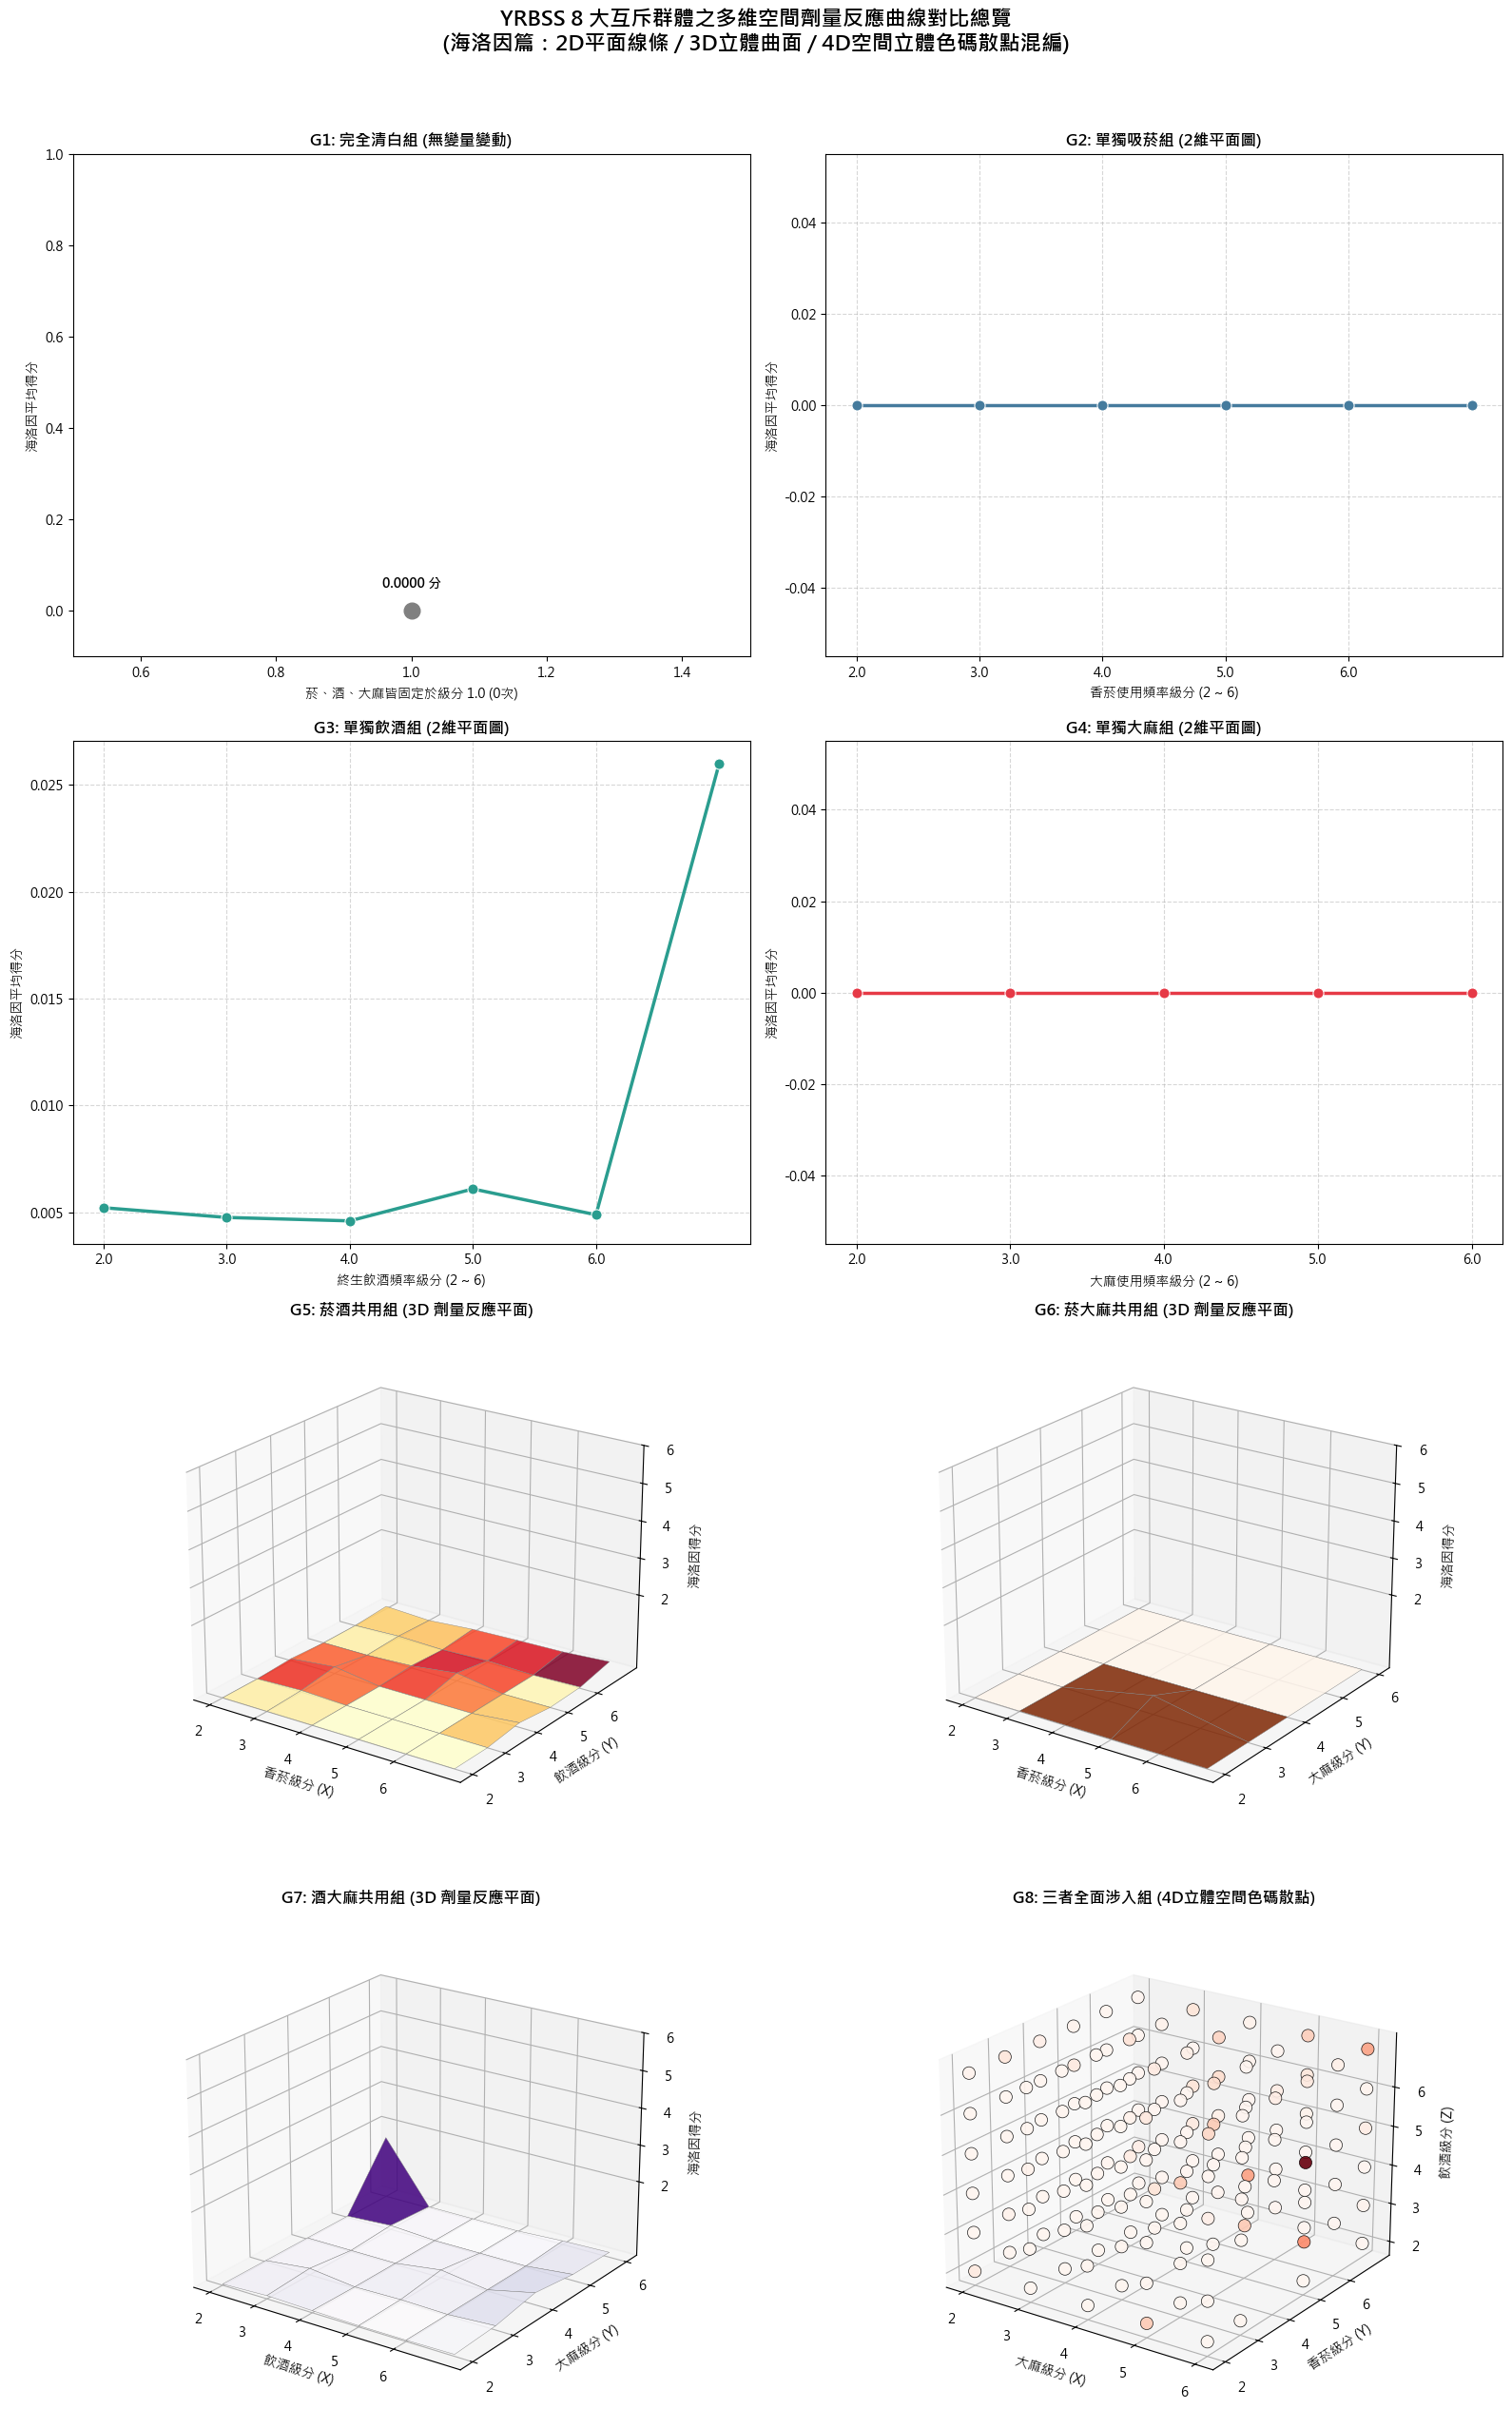

In [30]:
import os
import warnings
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # 導入 3D 繪圖引擎
import numpy as np                       # 用於建立 3D 網格矩陣
import seaborn as sns
import pandas as pd

# 設定中文字型與忽略警告訊息
warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']
plt.rcParams['axes.unicode_minus'] = False

print("正在繪製 8 大互斥群體之海洛因劑量效應多維度圖表...")

# 1. 確保海洛因得分已完成減 1 轉換 (0 代表從未吸食)
df_processed['Heroin_Score'] = df_processed['EverHeroinUse'] - 1

# 確保頻率皆為整數型態
df_processed['Cig_Int'] = df_processed['CurrentCigaretteUse'].astype(int)
df_processed['Alc_Int'] = df_processed['EverAlcoholUse'].astype(int)
df_processed['Mj_Int'] = df_processed['CurrentMarijuaUse'].astype(int)

# 2. 配置混合型 4x2 網格畫布 (個別指定 2D 與 3D 空間)
fig = plt.figure(figsize=(16, 26))
axes = {}
for i in range(8):
    if i in [4, 5, 6, 7]:  # G5, G6, G7, G8 指定為立體 3D 畫布
        axes[i] = fig.add_subplot(4, 2, i+1, projection='3d')
    else:                  # G1, G2, G3, G4 保持標準 2D 畫布
        axes[i] = fig.add_subplot(4, 2, i+1)

# =========================================================================
# 圖 1 (G1: 完全清白組) -> 0維固定點 (反映背景值平均數)
# =========================================================================
df_g1 = df_processed[df_processed['Substance_Group'].str.startswith('G1')]
g1_mean = df_g1['Heroin_Score'].mean()
axes[0].plot([1], [g1_mean], marker='o', markersize=12, color='gray')
axes[0].set_title('G1: 完全清白組 (無變量變動)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('菸、酒、大麻皆固定於級分 1.0 (0次)')
axes[0].set_ylabel('海洛因平均得分')
axes[0].set_xlim(0.5, 1.5)
axes[0].set_ylim(-0.1, 1.0)
axes[0].text(1, g1_mean + 0.05, f'{g1_mean:.4f} 分', ha='center', fontweight='bold')

# =========================================================================
# 圖 2 (G2: 單獨吸菸組) -> 2維平面圖
# =========================================================================
df_g2 = df_processed[df_processed['Substance_Group'].str.startswith('G2')]
sns.lineplot(data=df_g2, x='Cig_Int', y='Heroin_Score', marker='o', markersize=8, ax=axes[1], color='#457B9D', linewidth=2.5, errorbar=None)
axes[1].set_title('G2: 單獨吸菸組 (2維平面圖)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('香菸使用頻率級分 (2 ~ 6)')
axes[1].set_ylabel('海洛因平均得分')

# =========================================================================
# 圖 3 (G3: 單獨飲酒組) -> 2維平面圖
# =========================================================================
df_g3 = df_processed[df_processed['Substance_Group'].str.startswith('G3')]
sns.lineplot(data=df_g3, x='Alc_Int', y='Heroin_Score', marker='o', markersize=8, ax=axes[2], color='#2A9D8F', linewidth=2.5, errorbar=None)
axes[2].set_title('G3: 單獨飲酒組 (2維平面圖)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('終生飲酒頻率級分 (2 ~ 6)')
axes[2].set_ylabel('海洛因平均得分')

# =========================================================================
# 圖 4 (G4: 單獨大麻組) -> 2維平面圖
# =========================================================================
df_g4 = df_processed[df_processed['Substance_Group'].str.startswith('G4')]
sns.lineplot(data=df_g4, x='Mj_Int', y='Heroin_Score', marker='o', markersize=8, ax=axes[3], color='#E63946', linewidth=2.5, errorbar=None)
axes[3].set_title('G4: 單獨大麻組 (2維平面圖)', fontsize=12, fontweight='bold')
axes[3].set_xlabel('大麻使用頻率級分 (2 ~ 6)')
axes[3].set_ylabel('海洛因平均得分')

# =========================================================================
# 圖 5 (G5: 菸酒共用組) -> 3D 劑量反應平面
# =========================================================================
df_g5 = df_processed[df_processed['Substance_Group'].str.startswith('G5')]
g5_3d = df_g5.groupby(['Cig_Int', 'Alc_Int'])['Heroin_Score'].mean().reset_index()
pivot_g5 = g5_3d.pivot(index='Cig_Int', columns='Alc_Int', values='Heroin_Score').fillna(0)
X_g5, Y_g5 = np.meshgrid(pivot_g5.index.values, pivot_g5.columns.values)
Z_g5 = pivot_g5.values.T

surf5 = axes[4].plot_surface(X_g5, Y_g5, Z_g5, cmap='YlOrRd', edgecolor='gray', linewidth=0.3, alpha=0.85)
axes[4].set_title('G5: 菸酒共用組 (3D 劑量反應平面)', fontsize=12, fontweight='bold', pad=10)
axes[4].set_xlabel('香菸級分 (X)', fontsize=10)
axes[4].set_ylabel('飲酒級分 (Y)', fontsize=10)
axes[4].set_zlabel('海洛因得分', fontsize=10)
axes[4].view_init(elev=22, azim=-55)

# =========================================================================
# 圖 6 (G6: 菸大麻共用組) -> 3D 劑量反應平面
# =========================================================================
df_g6 = df_processed[df_processed['Substance_Group'].str.startswith('G6')]
g6_3d = df_g6.groupby(['Cig_Int', 'Mj_Int'])['Heroin_Score'].mean().reset_index()
pivot_g6 = g6_3d.pivot(index='Cig_Int', columns='Mj_Int', values='Heroin_Score').fillna(0)
X_g6, Y_g6 = np.meshgrid(pivot_g6.index.values, pivot_g6.columns.values)
Z_g6 = pivot_g6.values.T

surf6 = axes[5].plot_surface(X_g6, Y_g6, Z_g6, cmap='Oranges', edgecolor='gray', linewidth=0.3, alpha=0.85)
axes[5].set_title('G6: 菸大麻共用組 (3D 劑量反應平面)', fontsize=12, fontweight='bold', pad=10)
axes[5].set_xlabel('香菸級分 (X)', fontsize=10)
axes[5].set_ylabel('大麻級分 (Y)', fontsize=10)
axes[5].set_zlabel('海洛因得分', fontsize=10)
axes[5].view_init(elev=22, azim=-55)

# =========================================================================
# 圖 7 (G7: 酒大麻共用組) -> 3D 劑量反應平面
# =========================================================================
df_g7 = df_processed[df_processed['Substance_Group'].str.startswith('G7')]
g7_3d = df_g7.groupby(['Alc_Int', 'Mj_Int'])['Heroin_Score'].mean().reset_index()
pivot_g7 = g7_3d.pivot(index='Alc_Int', columns='Mj_Int', values='Heroin_Score').fillna(0)
X_g7, Y_g7 = np.meshgrid(pivot_g7.index.values, pivot_g7.columns.values)
Z_g7 = pivot_g7.values.T

surf7 = axes[6].plot_surface(X_g7, Y_g7, Z_g7, cmap='Purples', edgecolor='gray', linewidth=0.3, alpha=0.85)
axes[6].set_title('G7: 酒大麻共用組 (3D 劑量反應平面)', fontsize=12, fontweight='bold', pad=10)
axes[6].set_xlabel('飲酒級分 (X)', fontsize=10)
axes[6].set_ylabel('大麻級分 (Y)', fontsize=10)
axes[6].set_zlabel('海洛因得分', fontsize=10)
axes[6].view_init(elev=22, azim=-55)

# =========================================================================
# 圖 8 (G8: 三者全面涉入組) -> 4D 空間立體散點圖
# =========================================================================
df_g8 = df_processed[df_processed['Substance_Group'].str.startswith('G8')]
g8_4d_data = df_g8.groupby(['Mj_Int', 'Cig_Int', 'Alc_Int'])['Heroin_Score'].mean().reset_index()

sc8 = axes[7].scatter3D(
    g8_4d_data['Mj_Int'],     # X軸：大麻
    g8_4d_data['Cig_Int'],     # Y軸：香菸
    g8_4d_data['Alc_Int'],     # Z軸：酒精
    c=g8_4d_data['Heroin_Score'], 
    cmap='Reds', 
    s=90,                      # 散點數據標記大小
    edgecolor='black', 
    linewidth=0.5,
    alpha=0.9
)

axes[7].set_title('G8: 三者全面涉入組 (4D立體空間色碼散點)', fontsize=12, fontweight='bold', pad=10)
axes[7].set_xlabel('大麻級分 (X)', fontsize=10)
axes[7].set_ylabel('香菸級分 (Y)', fontsize=10)
axes[7].set_zlabel('飲酒級分 (Z)', fontsize=10)
axes[7].view_init(elev=22, azim=-55)

# 3. 配置各子圖之網格與刻度
for i in [1, 2, 3]: # 2D 平面組
    axes[i].set_xticks(range(2, 7))
    axes[i].set_xticklabels([f'{k}.0' for k in range(2, 7)])
    axes[i].grid(True, linestyle='--', alpha=0.5)

for i in [4, 5, 6, 7]: # 3D/4D 立體組
    axes[i].set_xticks(range(2, 7))
    axes[i].set_yticks(range(2, 7))
    axes[i].set_zticks(range(2, 7))
    axes[i].grid(True, linestyle='--', alpha=0.3)

# 4. 全域排版與標題優化
plt.suptitle('YRBSS 8 大互斥群體之多維空間劑量反應曲線對比總覽\n(海洛因篇：2D平面線條 / 3D立體曲面 / 4D空間立體色碼散點混編)', 
             fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])

# 5. 安全儲存高解析度圖檔
output_fig_path = '../outputs/figures/08_heroin_8_groups_dimensional_curves.png'
os.makedirs(os.path.dirname(output_fig_path), exist_ok=True)
plt.savefig(output_fig_path, dpi=300)

print(f"海洛因多維空間劑量反應圖繪製完成，圖檔已儲存至: {output_fig_path}")
plt.show()

In [31]:
import os
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

print("執行單因子變異數分析 (One-way ANOVA) 與 Tukey HSD 事後檢定...")
print("=" * 95)

# 1. 執行單因子變異數分析 (One-way ANOVA)
# 檢定虛無假設 H0: 8個互斥物質涉入群體的海洛因平均得分無顯著差異
formula_anova = 'Heroin_Score ~ C(Substance_Group)'
model_anova = ols(formula_anova, data=df_processed).fit()
anova_table = sm.stats.anova_lm(model_anova, typ=2)

print("【第一階段：ANOVA 變異數分析總表】")
print("-" * 95)
display(anova_table)
print("-" * 95)

# 2. 當 ANOVA 達到顯著水準時 (p < 0.05)，發動事後檢定
if anova_table['PR(>F)'].iloc[0] < 0.05:
    print(f"ANOVA 檢定結果達顯著水準 (p < 0.05)，拒絕虛無假設。")
    print("\n【第二階段：Tukey HSD 事後檢定 - 獨立篩選大麻效應對比組】")
    print("=" * 95)

    # 執行全組合配對比較 (事後檢定)
    tukey = pairwise_tukeyhsd(
        endog=df_processed['Heroin_Score'],
        groups=df_processed['Substance_Group'],
        alpha=0.05
    )

    # 將 Tukey 統計結果轉換為 DataFrame 格式
    tukey_df = pd.DataFrame(data=tukey.summary().data[1:], columns=tukey.summary().data[0])

    # 定義用於評估「加入大麻行為」之前後對照組
    core_marijuana_pairs = [
        ("G1: 完全清白組 (None)", "G4: 單獨大麻組 (Mj Only)"),
        ("G2: 單獨吸菸組 (Cig Only)", "G6: 菸大麻共用組 (Cig + Mj)"),
        ("G3: 單獨飲酒組 (Alc Only)", "G7: 酒大麻共用組 (Alc + Mj)"),
        ("G5: 菸酒共用組 (Cig + Alc)", "G8: 三者全面涉入組 (All Three)")
    ]

    filtered_results = []
    for g1, g2 in core_marijuana_pairs:
        match = tukey_df[((tukey_df['group1'] == g1) & (tukey_df['group2'] == g2)) |
                         ((tukey_df['group1'] == g2) & (tukey_df['group2'] == g1))]
        filtered_results.append(match)

    # 彙整篩選後之核心對比數據
    summary_tukey = pd.concat(filtered_results).reset_index(drop=True)
    
    # 重新定義欄位名稱以符合學術報告格式 (完整對齊 7 個統計欄位)
    summary_tukey.columns = ['組別 A', '組別 B', '平均得分差 (meandiff)', '調整後 p 值 (p-adj)', '下界 (lower)', '上界 (upper)', '顯著拒絕 (reject)']

    # 建立具學術定義之統計推論結論標籤
    summary_tukey['統計學結論'] = summary_tukey['顯著拒絕 (reject)'].apply(
        lambda x: "顯著差異 (具大麻加乘效應)" if x else "無顯著差異"
    )

    # 顯示分析結果總表
    display(summary_tukey[['組別 A', '組別 B', '平均得分差 (meandiff)', '調整後 p 值 (p-adj)', '顯著拒絕 (reject)', '統計學結論']])
    print("-" * 95)

    # =========================================================================
    # 數據匯出管線：將 Tukey HSD 篩選結果儲存至指定目錄
    # =========================================================================
    print('正在將海洛因事後檢定核心數據匯出為實體表格檔案...')

    output_dir = '../outputs/tables/'
    os.makedirs(output_dir, exist_ok=True)

    # 設定實體檔案路徑
    output_file_path = os.path.join(output_dir, '07_heroin_impact_tukey.csv')

    # 以 utf-8-sig 編碼儲存以確保 CSV 檔案之中文內容正常顯示
    summary_tukey.to_csv(output_file_path, index=False, encoding='utf-8-sig')

    print(f"數據匯出完成。檔案路徑: {output_file_path}")
    print("=" * 95)
else:
    print("ANOVA 檢定結果未達顯著水準，不予執行事後檢定。")
    print("=" * 95)

執行單因子變異數分析 (One-way ANOVA) 與 Tukey HSD 事後檢定...
【第一階段：ANOVA 變異數分析總表】
-----------------------------------------------------------------------------------------------


,sum_sq,df,F,PR(>F)
C(Substance_Group),93.024465,7.0,87.498209,8.024626e-125
Residual,1835.467224,12085.0,NaN,NaN


-----------------------------------------------------------------------------------------------
ANOVA 檢定結果達顯著水準 (p < 0.05)，拒絕虛無假設。

【第二階段：Tukey HSD 事後檢定 - 獨立篩選大麻效應對比組】


,組別 A,組別 B,平均得分差 (meandiff),調整後 p 值 (p-adj),顯著拒絕 (reject),統計學結論
0,G1: 完全清白組 (None),G4: 單獨大麻組 (Mj Only),0.0000,1.0000,False,無顯著差異
1,G2: 單獨吸菸組 (Cig Only),G6: 菸大麻共用組 (Cig + Mj),0.0588,0.9994,False,無顯著差異
2,G3: 單獨飲酒組 (Alc Only),G7: 酒大麻共用組 (Alc + Mj),0.0346,0.1772,False,無顯著差異
3,G5: 菸酒共用組 (Cig + Alc),G8: 三者全面涉入組 (All Three),0.2371,0.0000,True,顯著差異 (具大麻加乘效應)


-----------------------------------------------------------------------------------------------
正在將海洛因事後檢定核心數據匯出為實體表格檔案...
數據匯出完成。檔案路徑: ../outputs/tables/07_heroin_impact_tukey.csv
